# Assignment 2 — E-Commerce Sales Analysis

This notebook loads, cleans, transforms, and analyzes `ecommerce_orders_raw.csv` using Pandas, Matplotlib, and Seaborn.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Find the repository/assignment data folder
for candidate in (Path.cwd(), Path.cwd().parent, Path.cwd() / "Day 4" / "Assignment 2"):
    if (candidate / "data").exists():
        BASE = candidate
        break
else:
    raise FileNotFoundError("Run this notebook from the repository or assignment folder.")

DATA = BASE / "data"
OUTPUT = BASE / "output"
OUTPUT.mkdir(exist_ok=True)

print("Base path:", BASE)

Base path: d:\IIT-M\Day 4\Assignment 2


## Part A — Data Understanding

In [2]:
# 1. Load dataset
df = pd.read_csv(DATA / "ecommerce_orders_raw.csv")

# 2. Display structure and dimensions
print("Shape:", df.shape)
display(df.head())

# 3. Data types
print("\nData types:")
print(df.dtypes)

# 4. Missing values
print("\nMissing values:")
print(df.isna().sum())

# 5. Duplicate orders
duplicate_orders = df[df.duplicated(subset="Order_ID", keep=False)]
print("\nDuplicate order rows:", len(duplicate_orders))
display(duplicate_orders.head(10))

# 6. Unique values
for column in ["City", "Product_Category", "Payment_Method"]:
    print(f"\n{column} unique values:")
    print(df[column].dropna().unique())

Shape: (15100, 11)


,Order_ID,Customer_ID,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating
0,O014846,C00722,Delhi,Home Appliances,Mixer,2,10042.08,10,Debit Card,2026-07-25 02:03:50.895393024,4.0
1,O014121,C01623,Pune,Books,Novel,1,34791.00,15,Debit Card,2026-06-27 05:51:34.526301752,1.0
2,O014861,C01543,Hyderabad,Home Appliances,Mixer,2,15693.00,15,Net Banking,2026-07-25 15:53:20.613374224,4.0
3,O000885,C02287,Mumbai,Books,Biography,5,72700.86,20,Debit Card,2025-02-03 22:44:55.379691979,3.0
4,O000412,C00051,Mumbai,Beauty,Shampoo,5,89712.89,25,UPI,2025-01-16 18:48:10.272684845,5.0



Data types:
Order_ID                str
Customer_ID             str
City                    str
Product_Category        str
Product                 str
Quantity              int64
Unit_Price          float64
Discount              int64
Payment_Method          str
Order_Date              str
Rating              float64
dtype: object

Missing values:
Order_ID              0
Customer_ID           0
City                  0
Product_Category      0
Product               0
Quantity              0
Unit_Price            0
Discount              0
Payment_Method        0
Order_Date            0
Rating              401
dtype: int64

Duplicate order rows: 200


,Order_ID,Customer_ID,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating
80,O002885,C02097,chennai,Sports,Football,5,38250.93,5,Cash on Delivery,2025-04-21 18:04:17.777185146,3.0
92,O007041,C02500,Mumbai,Beauty,Perfume,2,80414.95,20,Debit Card,2025-09-28 08:29:47.639175944,4.0
105,O011596,C02579,Chennai,Sports,Football,1,22841.99,25,Cash on Delivery,2026-03-22 06:39:51.999466632,5.0
110,O000863,C02682,Pune,Clothing,Jacket,5,90966.80,20,UPI,2025-02-03 02:28:19.793319554,2.0
119,O002627,C02398,Delhi,Home Appliances,Air Purifier,3,74694.80,15,Credit Card,2025-04-11 20:16:58.627908527,5.0
131,O000170,C01364,Coimbatore,Books,Self Help,4,40728.61,15,UPI,2025-01-07 11:45:38.822588172,4.0
146,O000543,C00418,Kolkata,Books,Textbook,2,21539.90,20,Credit Card,2025-01-21 19:32:25.809720648,4.0
151,O000150,C01924,Chennai,Clothing,Jeans,2,77799.22,25,UPI,2025-01-06 17:19:39.198613240,3.0
170,O000252,C02977,Delhi,Clothing,Jacket,1,96105.40,0,Net Banking,2025-01-10 15:20:13.280885392,1.0
185,O011500,C00913,Mumbai,Sports,Running Shoes,5,93171.66,5,Cash on Delivery,2026-03-18 14:11:05.804386960,4.0



City unique values:
<StringArray>
[     'Delhi',       'Pune',  'Hyderabad',     'Mumbai',    'Kolkata',
  'Bangalore',  ' chennai ',    'Chennai', 'Coimbatore',    'CHENNAI']
Length: 10, dtype: str

Product_Category unique values:
<StringArray>
['Home Appliances', 'Books', 'Beauty', 'Sports', 'Clothing', 'Electronics']
Length: 6, dtype: str

Payment_Method unique values:
<StringArray>
['Debit Card', 'Net Banking', 'UPI', 'Credit Card', 'Cash on Delivery']
Length: 5, dtype: str


## Part B — Data Cleaning

In [3]:
# 7. Handle missing ratings
rating_median = df["Rating"].median()
df["Rating"] = df["Rating"].fillna(rating_median)

# 8. Standardize city names
df["City"] = df["City"].astype("string").str.strip().str.title()

# 9. Identify and handle invalid quantities
invalid_quantity = df[df["Quantity"] <= 0]
print("Invalid quantity rows:", len(invalid_quantity))
if not invalid_quantity.empty:
    display(invalid_quantity)

df = df[df["Quantity"] > 0].copy()

# 10. Handle duplicate orders
before_duplicates = len(df)
df = df.drop_duplicates(subset="Order_ID").copy()
print("Duplicate order rows removed:", before_duplicates - len(df))

# 11. Convert Order_Date to datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
print("Invalid dates after conversion:", df["Order_Date"].isna().sum())

print("\nCleaned shape:", df.shape)
display(df.head())

Invalid quantity rows: 20


,Order_ID,Customer_ID,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating
101,O012623,C02458,Delhi,Home Appliances,Vacuum Cleaner,-2,17821.53,5,UPI,2026-04-30 17:12:38.690579368,5.0
476,O004601,C02136,Chennai,Clothing,Jeans,-2,96639.36,20,UPI,2025-06-26 15:38:33.514234282,4.0
1639,O006694,C01856,Pune,Sports,Football,-2,44119.66,0,Net Banking,2025-09-15 00:40:48.163210880,4.0
2420,O007460,C02632,Bangalore,Electronics,Smart Watch,-2,68963.12,0,Debit Card,2025-10-14 10:40:21.761450764,5.0
4496,O002305,C01604,Kolkata,Sports,Cricket Bat,-2,21758.55,25,Net Banking,2025-03-30 11:30:28.681912127,5.0
4861,O012185,C00664,Chennai,Books,Novel,-2,40781.24,25,UPI,2026-04-13 21:31:22.925528368,1.0
5008,O001742,C02508,Pune,Books,Self Help,-2,56782.27,20,Net Banking,2025-03-08 20:36:45.267017801,3.0
6591,O011832,C02379,Hyderabad,Electronics,Smartphone,-2,75507.40,0,Debit Card,2026-03-31 08:10:35.562370824,5.0
8972,O002382,C00456,Kolkata,Clothing,Shoes,-2,62380.34,25,Debit Card,2025-04-02 10:28:33.234215614,4.0
9230,O008580,C01669,Kolkata,Clothing,Jacket,-2,14579.25,20,Debit Card,2025-11-26 10:56:00.704046936,3.0


Duplicate order rows removed: 100
Invalid dates after conversion: 0

Cleaned shape: (14980, 11)


,Order_ID,Customer_ID,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating
0,O014846,C00722,Delhi,Home Appliances,Mixer,2,10042.08,10,Debit Card,2026-07-25 02:03:50.895393024,4.0
1,O014121,C01623,Pune,Books,Novel,1,34791.00,15,Debit Card,2026-06-27 05:51:34.526301752,1.0
2,O014861,C01543,Hyderabad,Home Appliances,Mixer,2,15693.00,15,Net Banking,2026-07-25 15:53:20.613374224,4.0
3,O000885,C02287,Mumbai,Books,Biography,5,72700.86,20,Debit Card,2025-02-03 22:44:55.379691979,3.0
4,O000412,C00051,Mumbai,Beauty,Shampoo,5,89712.89,25,UPI,2025-01-16 18:48:10.272684845,5.0


## Part C — Feature Engineering

In [4]:
# 12. Gross Amount
df["Gross_Amount"] = df["Quantity"] * df["Unit_Price"]

# 13. Discount Amount
df["Discount_Amount"] = df["Gross_Amount"] * df["Discount"] / 100

# 14. Net Amount
df["Net_Amount"] = df["Gross_Amount"] - df["Discount_Amount"]

# 15. Rating Category
rating_categories = {
    1: "Poor",
    2: "Poor",
    3: "Average",
    4: "Good",
    5: "Excellent"
}
df["Rating_Category"] = df["Rating"].round().map(rating_categories)

# 16. Extract date components
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df["Day"] = df["Order_Date"].dt.day
df["Day_of_Week"] = df["Order_Date"].dt.day_name()

display(df.head())

,Order_ID,Customer_ID,City,Product_Category,Product,Quantity,Unit_Price,Discount,Payment_Method,Order_Date,Rating,Gross_Amount,Discount_Amount,Net_Amount,Rating_Category,Year,Month,Day,Day_of_Week
0,O014846,C00722,Delhi,Home Appliances,Mixer,2,10042.08,10,Debit Card,2026-07-25 02:03:50.895393024,4.0,20084.16,2008.4160,18075.7440,Good,2026,2026-07,25,Saturday
1,O014121,C01623,Pune,Books,Novel,1,34791.00,15,Debit Card,2026-06-27 05:51:34.526301752,1.0,34791.00,5218.6500,29572.3500,Poor,2026,2026-06,27,Saturday
2,O014861,C01543,Hyderabad,Home Appliances,Mixer,2,15693.00,15,Net Banking,2026-07-25 15:53:20.613374224,4.0,31386.00,4707.9000,26678.1000,Good,2026,2026-07,25,Saturday
3,O000885,C02287,Mumbai,Books,Biography,5,72700.86,20,Debit Card,2025-02-03 22:44:55.379691979,3.0,363504.30,72700.8600,290803.4400,Average,2025,2025-02,3,Monday
4,O000412,C00051,Mumbai,Beauty,Shampoo,5,89712.89,25,UPI,2025-01-16 18:48:10.272684845,5.0,448564.45,112141.1125,336423.3375,Excellent,2025,2025-01,16,Thursday


## Part D — Business Analysis

In [5]:
# 17. Total revenue
total_revenue = df["Net_Amount"].sum()

# 18. Total number of orders
total_orders = df["Order_ID"].nunique()

# 19. Average order value
order_totals = df.groupby("Order_ID")["Net_Amount"].sum()
average_order_value = order_totals.mean()

# 20. Revenue by product category
revenue_by_category = (
    df.groupby("Product_Category")["Net_Amount"]
    .sum()
    .sort_values(ascending=False)
)

# 21. Top 10 products by revenue
top_products = df.groupby("Product")["Net_Amount"].sum().nlargest(10)

# 22. City generating highest revenue
revenue_by_city = df.groupby("City")["Net_Amount"].sum().sort_values(ascending=False)
top_city = revenue_by_city.idxmax()

# 23. Most frequently used payment method
payment_method = df["Payment_Method"].mode().iat[0]

# 24. Average rating by product category
average_rating_by_category = df.groupby("Product_Category")["Rating"].mean().sort_values(ascending=False)

# 25. Monthly revenue
monthly_revenue = df.groupby("Month")["Net_Amount"].sum()

# 26. Highest-revenue month
highest_revenue_month = monthly_revenue.idxmax()

# 27. Top 10 customers by total spending
top_customers = df.groupby("Customer_ID")["Net_Amount"].sum().nlargest(10)

# 28. Compare revenue by cities
print("Revenue by city:")
display(revenue_by_city.to_frame("Revenue"))

# 29. Highest average order value by product category
# If an order contains multiple categories, this assigns the order's total to each category present.
order_category = df[["Order_ID", "Product_Category"]].drop_duplicates()
category_aov = (
    order_category
    .merge(order_totals.rename("Order_Total"), on="Order_ID")
    .groupby("Product_Category")["Order_Total"]
    .mean()
    .sort_values(ascending=False)
)
highest_aov_category = category_aov.idxmax()

summary = pd.Series({
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Average Order Value": average_order_value,
    "Highest Revenue City": top_city,
    "Most Used Payment Method": payment_method,
    "Highest Revenue Month": highest_revenue_month,
    "Highest AOV Category": highest_aov_category,
})

print("Business Summary:")
display(summary.to_frame("Value"))

print("Top 10 Products by Revenue:")
display(top_products.to_frame("Revenue"))

print("Average Rating by Product Category:")
display(average_rating_by_category.to_frame("Average Rating"))

print("Top 10 Customers by Spending:")
display(top_customers.to_frame("Total Spending"))

print("Revenue by Product Category:")
display(revenue_by_category.to_frame("Revenue"))

print("Monthly Revenue:")
display(monthly_revenue.to_frame("Revenue"))

print("Average Order Value by Product Category:")
display(category_aov.to_frame("Average Order Value"))

Revenue by city:


,Revenue
City,
Chennai,2.853485e+08
Mumbai,2.478145e+08
Coimbatore,2.462794e+08
Delhi,2.462605e+08
Pune,2.438330e+08
Bangalore,2.397697e+08
Kolkata,2.392708e+08
Hyderabad,2.326976e+08


Business Summary:


,Value
Total Revenue,1981274066.4005
Total Orders,14980
Average Order Value,132261.286142
Highest Revenue City,Chennai
Most Used Payment Method,Cash on Delivery
Highest Revenue Month,2026-01
Highest AOV Category,Clothing


Top 10 Products by Revenue:


...

,Revenue
Product_Category,
Clothing,3.454173e+08
Books,3.327768e+08
Beauty,3.309898e+08
Sports,3.296359e+08
Electronics,3.235178e+08
Home Appliances,3.189363e+08


Monthly Revenue:


,Revenue
Month,
2025-01,1.079406e+08
2025-02,9.685231e+07
2025-03,1.058758e+08
2025-04,1.073236e+08
2025-05,1.063948e+08
2025-06,1.024020e+08
2025-07,1.074132e+08
2025-08,1.072570e+08
2025-09,1.083384e+08


Average Order Value by Product Category:


,Average Order Value
Product_Category,
Clothing,135351.615454
Sports,133240.074519
Books,132001.919537
Beauty,131763.472811
Electronics,130872.902512
Home Appliances,130231.237869


## Visualizations

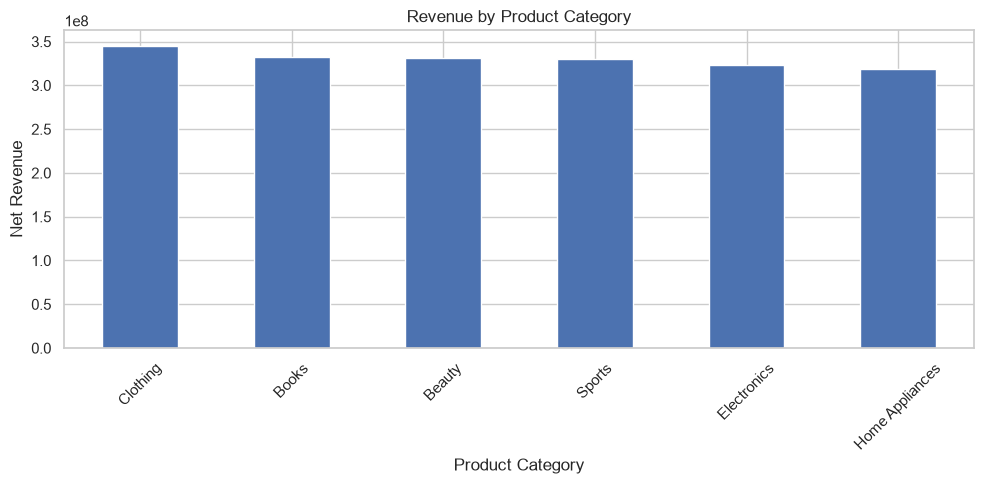

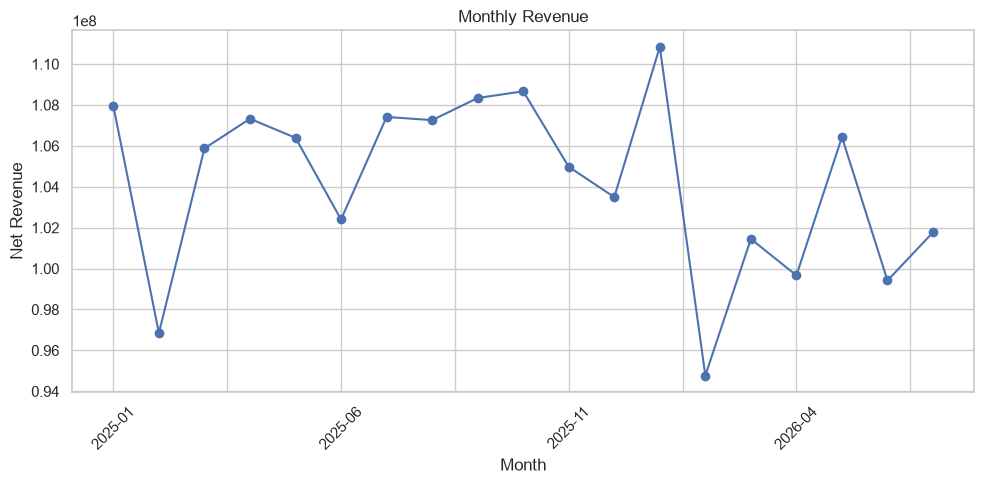

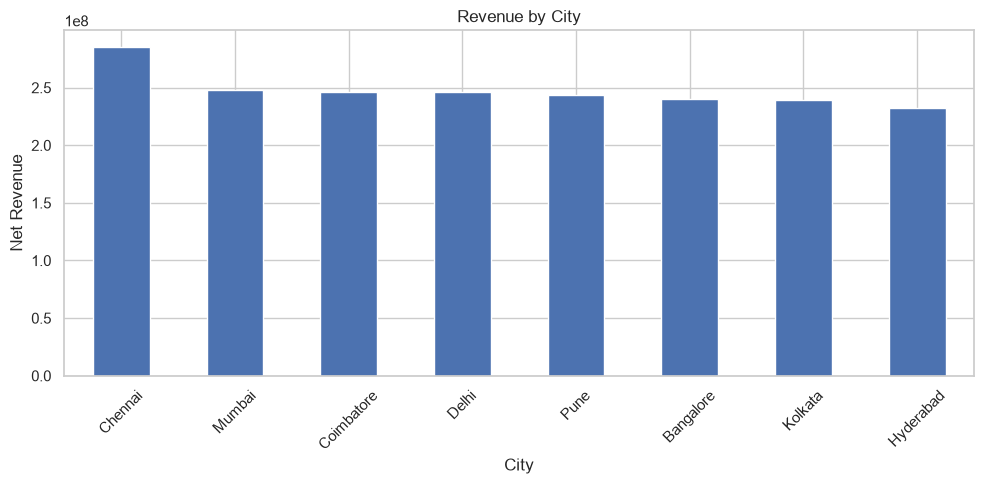

In [6]:
sns.set_theme(style="whitegrid")

# Revenue by product category
plt.figure(figsize=(10, 5))
revenue_by_category.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "revenue_by_category.png", dpi=150)
plt.show()
plt.close()

# Monthly revenue
plt.figure(figsize=(10, 5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "monthly_revenue.png", dpi=150)
plt.show()
plt.close()

# Revenue by city
plt.figure(figsize=(10, 5))
revenue_by_city.plot(kind="bar")
plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Net Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT / "revenue_by_city.png", dpi=150)
plt.show()
plt.close()

## Save Cleaned Dataset

In [7]:
cleaned_file = OUTPUT / "ecommerce_orders_cleaned.csv"
df.to_csv(cleaned_file, index=False)
print("Cleaned dataset saved to:", cleaned_file)

Cleaned dataset saved to: d:\IIT-M\Day 4\Assignment 2\output\ecommerce_orders_cleaned.csv
